In [31]:
from PyHessian.pyhessian.hessian import hessian
from PyHessian.density_plot import get_esd_plot
from hessian_utils import *
from PyHessian.pyhessian.utils import *
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms
# from keras.datasets import mnist
import matplotlib.pyplot as plt 
import time
import copy


# PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
%matplotlib inline

In [32]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)
cuda = torch.cuda.is_available()
torch.autograd.set_detect_anomaly(True)

cuda


In [33]:
mnist_trainset = datasets.MNIST(root='../data/mnist', train=True, download=True, transform=transforms.ToTensor())
mnist_fashion_trainset = datasets.FashionMNIST(root='../data/fashion_mnist', train=True, download=True, transform=transforms.ToTensor())
cifar_trainset = datasets.CIFAR10(root='../data/cifar10', train=True, download=True, transform=transforms.ToTensor())
# Getting mnist test data
mnist_testset = datasets.MNIST(root='../data/mnist', train=False, download=True, transform=transforms.ToTensor())
mnist_fashion_testset = datasets.FashionMNIST(root='../data/fashion_mnist', train=False, download=True, transform=transforms.ToTensor())
cifar_testset = datasets.CIFAR10(root='../data/cifar10', train=False, download=True, transform=transforms.ToTensor())

In [34]:
train_X = cifar_trainset.data
train_y = cifar_trainset.targets
test_X = cifar_testset.data
test_y = cifar_testset.targets

In [35]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 100)
        self.fc2 = nn.Linear(100, 30)
        self.fc3 = nn.Linear(30, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(10, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(16*7*7, 16),
            nn.ReLU(),
            nn.Linear(16, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 16*7*7)
        x = self.linear(x)
        return x

class ConvNet3D(nn.Module):
    def __init__(self):
        super(ConvNet3D, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 20, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 40, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.linear = nn.Sequential(
            nn.Linear(40*8*8, 30),
            nn.ReLU(),
            nn.Linear(30, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(-1, 40*8*8)
        x = self.linear(x)
        return x

In [36]:
train_X = torch.tensor(train_X).permute(0, 3, 1, 2).float()
test_X = torch.tensor(test_X).permute(0, 3, 1, 2).float()
train_X = (train_X / 255.0).to(device)
test_X = (test_X / 255.0).to(device)
train_y = torch.tensor(train_y, dtype=torch.int64).to(device)
test_y = torch.tensor(test_y, dtype=torch.int64).to(device)

In [37]:
torch.manual_seed(42)
np.random.seed(42)
n_samples = 1000
batch_size = 32

In [38]:
train_X = train_X[:n_samples]
train_y = train_y[:n_samples]

dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_X, train_y),
    batch_size=batch_size, shuffle=True)

In [39]:
criterion_SGD = nn.CrossEntropyLoss()
criterion_Adam = nn.CrossEntropyLoss()
criterion_Curvy = nn.CrossEntropyLoss()

model_base = ConvNet3D().to(device)
model_SGD = copy.deepcopy(model_base)
model_Adam = copy.deepcopy(model_base)
model_curvy = copy.deepcopy(model_base)

In [40]:
train_losses_SGD = []
train_losses_Adam = []
train_losses_curvy = []

model_distance_SGD = []
model_distance_Adam = []
model_distance_curvy = []

In [41]:
def mean_curvature(curvature):
    return [torch.tensor(np.mean([curvature[i][j] for i in range(len(curvature))], axis=0)).to(device) for j in range(len(curvature[0]))]

def distance(model1, model2):
    return sum([torch.norm(p1 - p2) for p1, p2 in zip(model1.parameters(), model2.parameters())])

def get_loss(model, loader, criterion):
    total_loss = 0
    total_items = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss_value = criterion(outputs, labels)
            total_loss += loss_value.item() * inputs.size(0)
            total_items += inputs.size(0)
    return total_loss / total_items

In [42]:
epochs = 30
n_iter = 100
n_hess_samples = 50
adam_lr = 5e-3
sgd_lr = 1e-2
curvy_lr = 1e-1
curvy_eps = 1
sgd_mom = 0.9
curvy_mom = 0.9

In [43]:
criterion = nn.CrossEntropyLoss()
optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=sgd_lr, momentum=sgd_mom)
optimizer_Adam = torch.optim.Adam(model_Adam.parameters(), lr=adam_lr)
optimizer_curvy = torch.optim.SGD(model_curvy.parameters(), lr=curvy_lr, momentum=curvy_mom)

In [44]:
hessian_loader = (train_X[:n_hess_samples], train_y[:n_hess_samples])

hessian_SGD = hessian(model_SGD, criterion, data = hessian_loader, cuda=cuda)
hessian_Adam = hessian(model_Adam, criterion, data = hessian_loader, cuda=cuda)
hessian_curvy = hessian(model_curvy, criterion, data = hessian_loader, cuda=cuda)

curvature_SGD = (hessian_SGD.curvature_array(n_iter, 1e-3))
curvature_Adam = (hessian_Adam.curvature_array(n_iter, 1e-3))
curvature_curvy = (hessian_curvy.curvature_array(n_iter, 1e-3))

mean_curvature_SGD = mean_curvature(curvature_SGD)
mean_curvature_Adam = mean_curvature(curvature_Adam)
mean_curvature_curvy = mean_curvature(curvature_curvy)

model_distance_SGD.append(distance(model_SGD, model_base))
model_distance_Adam.append(distance(model_Adam, model_base))
model_distance_curvy.append(distance(model_curvy, model_base))

In [49]:
def train_model(model, optimizer, criterion, dataloader, epochs):
    model.train()
    train_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(dataloader.dataset)
        # print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
        train_losses.append(epoch_loss)
    return get_loss(model, dataloader, criterion), np.mean(train_losses)

def train_model_curvy(model, optimizer, eps, criterion, dataloader, epochs):
    model.train()
    train_losses = []

    for epoch in range(epochs):
        
        indices = torch.randperm(train_X.size(0))[:n_hess_samples]
        hessian_loader = (train_X[indices], train_y[indices])
        hessian_curvy = hessian(model, criterion, data = hessian_loader, cuda=cuda)
        curvature_curvy = (hessian_curvy.curvature_array(n_iter, 1e-3))
        mean_curvature_curvy = mean_curvature(curvature_curvy)
        
        model.train()
        running_loss = 0.0
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            if loss.item() > 10:
                return get_loss(model, dataloader, criterion), np.mean(train_losses)
            loss.backward()
            for param, cur in zip(model_curvy.parameters(), mean_curvature_curvy):
                if param.grad is None:
                    continue
                param.grad = param.grad/torch.max(torch.abs(cur), torch.ones_like(cur) * eps)

            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(dataloader.dataset)
        # print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
        train_losses.append(epoch_loss)
    
    return get_loss(model, dataloader, criterion), np.mean(train_losses)

In [54]:
adam_lrs = [1e-1, 1e-2, 5e-3, 1e-3, 1e-4]
adam_lr_losses = []

In [55]:
for adam_lr in adam_lrs:
    print(f"Training with Adam optimizer, learning rate: {adam_lr}")
    model_Adam = copy.deepcopy(model_base)
    optimizer_Adam = torch.optim.Adam(model_Adam.parameters(), lr=adam_lr)
    train_loss, mean_train_loss = train_model(model_Adam, optimizer_Adam, criterion_Adam, dataloader, epochs)
    adam_lr_losses.append((adam_lr, train_loss, mean_train_loss))
    print(f"lr: {adam_lr}, Train Loss: {train_loss:.4f}, Mean Train Loss: {mean_train_loss:.4f}")
adam_lr_losses = sorted(adam_lr_losses, key=lambda x: x[1])
print("Adam learning rates and corresponding losses:")
for lr, loss, mean_loss in adam_lr_losses:
    print(f"lr: {lr}, Train Loss: {loss:.4f}, Mean Train Loss: {mean_loss:.4f}")

Training with Adam optimizer, learning rate: 0.1
lr: 0.1, Train Loss: 2.3040, Mean Train Loss: 2.7490
Training with Adam optimizer, learning rate: 0.01
lr: 0.01, Train Loss: 0.3912, Mean Train Loss: 0.8549
Training with Adam optimizer, learning rate: 0.005
lr: 0.005, Train Loss: 0.1126, Mean Train Loss: 0.9746
Training with Adam optimizer, learning rate: 0.001
lr: 0.001, Train Loss: 0.5045, Mean Train Loss: 1.2703
Training with Adam optimizer, learning rate: 0.0001
lr: 0.0001, Train Loss: 1.6713, Mean Train Loss: 1.9418
Adam learning rates and corresponding losses:
lr: 0.005, Train Loss: 0.1126, Mean Train Loss: 0.9746
lr: 0.01, Train Loss: 0.3912, Mean Train Loss: 0.8549
lr: 0.001, Train Loss: 0.5045, Mean Train Loss: 1.2703
lr: 0.0001, Train Loss: 1.6713, Mean Train Loss: 1.9418
lr: 0.1, Train Loss: 2.3040, Mean Train Loss: 2.7490


In [57]:
adam_lr_losses.sort(key=lambda x: x[1])
print("Adam learning rates and corresponding losses:")
for lr, loss, mean_loss in adam_lr_losses:
    print(f"Learning rate: {lr}, Loss: {loss:.4f}, Mean Loss: {mean_loss:.4f}")

Adam learning rates and corresponding losses:
Learning rate: 0.005, Loss: 0.1126, Mean Loss: 0.9746
Learning rate: 0.01, Loss: 0.3912, Mean Loss: 0.8549
Learning rate: 0.001, Loss: 0.5045, Mean Loss: 1.2703
Learning rate: 0.0001, Loss: 1.6713, Mean Loss: 1.9418
Learning rate: 0.1, Loss: 2.3040, Mean Loss: 2.7490


In [52]:
sgd_lrs = [1e-1, 1e-2, 5e-3, 1e-3, 1e-4]
sgd_moms = [0.9, 0.5, 0.0]
sgd_lr_losses = []
for sgd_lr in sgd_lrs:
    for sgd_mom in sgd_moms:
        print(f"Training with SGD optimizer, learning rate: {sgd_lr}, momentum: {sgd_mom}")
        model_SGD = copy.deepcopy(model_base)
        optimizer_SGD = torch.optim.SGD(model_SGD.parameters(), lr=sgd_lr, momentum=sgd_mom)
        train_loss, mean_train_loss = train_model(model_SGD, optimizer_SGD, criterion_SGD, dataloader, epochs)
        sgd_lr_losses.append((sgd_lr, sgd_mom, train_loss, mean_train_loss))
        print(f"Training with SGD optimizer, learning rate: {sgd_lr}, momentum: {sgd_mom}, loss: {train_loss:.4f}, mean loss: {mean_train_loss:.4f}")
sgd_lr_losses.sort(key=lambda x: x[1])
print("SGD learning rates and corresponding losses:")
for lr, mom, loss, mean_loss in sgd_lr_losses:
    print(f"Learning rate: {lr}, Momentum: {mom}, Loss: {loss:.4f}, Mean Loss: {mean_loss:.4f}")


Training with SGD optimizer, learning rate: 0.1, momentum: 0.9
Training with SGD optimizer, learning rate: 0.1, momentum: 0.9, loss: 1.2332, mean loss: 1.8315
Training with SGD optimizer, learning rate: 0.1, momentum: 0.5
Training with SGD optimizer, learning rate: 0.1, momentum: 0.5, loss: 0.6417, mean loss: 1.3948
Training with SGD optimizer, learning rate: 0.1, momentum: 0.0
Training with SGD optimizer, learning rate: 0.1, momentum: 0.0, loss: 1.6949, mean loss: 1.7858
Training with SGD optimizer, learning rate: 0.01, momentum: 0.9
Training with SGD optimizer, learning rate: 0.01, momentum: 0.9, loss: 0.2670, mean loss: 1.4935
Training with SGD optimizer, learning rate: 0.01, momentum: 0.5
Training with SGD optimizer, learning rate: 0.01, momentum: 0.5, loss: 1.7388, mean loss: 2.0901
Training with SGD optimizer, learning rate: 0.01, momentum: 0.0
Training with SGD optimizer, learning rate: 0.01, momentum: 0.0, loss: 2.1252, mean loss: 2.2720
Training with SGD optimizer, learning ra

In [53]:
sgd_lr_losses.sort(key=lambda x: x[2])
print("SGD learning rates and corresponding losses:")
for lr, mom, loss, mean_loss in sgd_lr_losses:
    print(f"Learning rate: {lr}, Momentum: {mom}, Loss: {loss:.4f}, Mean Loss: {mean_loss:.4f}")


SGD learning rates and corresponding losses:
Learning rate: 0.01, Momentum: 0.9, Loss: 0.2670, Mean Loss: 1.4935
Learning rate: 0.1, Momentum: 0.5, Loss: 0.6417, Mean Loss: 1.3948
Learning rate: 0.005, Momentum: 0.9, Loss: 1.0747, Mean Loss: 1.8212
Learning rate: 0.1, Momentum: 0.9, Loss: 1.2332, Mean Loss: 1.8315
Learning rate: 0.1, Momentum: 0.0, Loss: 1.6949, Mean Loss: 1.7858
Learning rate: 0.01, Momentum: 0.5, Loss: 1.7388, Mean Loss: 2.0901
Learning rate: 0.01, Momentum: 0.0, Loss: 2.1252, Mean Loss: 2.2720
Learning rate: 0.005, Momentum: 0.5, Loss: 2.1327, Mean Loss: 2.2721
Learning rate: 0.001, Momentum: 0.9, Loss: 2.1558, Mean Loss: 2.2761
Learning rate: 0.005, Momentum: 0.0, Loss: 2.2876, Mean Loss: 2.2982
Learning rate: 0.001, Momentum: 0.5, Loss: 2.2998, Mean Loss: 2.3027
Learning rate: 0.001, Momentum: 0.0, Loss: 2.3025, Mean Loss: 2.3040
Learning rate: 0.0001, Momentum: 0.9, Loss: 2.3026, Mean Loss: 2.3041
Learning rate: 0.0001, Momentum: 0.5, Loss: 2.3049, Mean Loss: 2.3

In [47]:
curvy_lrs = [1e-4, 1e-3, 1e-2, 1e-1]
curvy_eps = [1e-4, 1e-3, 1e-2, 1e-1]
curvy_moms = [0.9, 0.0]
curvy_lr_losses = []

In [50]:
for li in range(len(curvy_lrs)):
    curvy_lr = curvy_lrs[li]
    for epsilon in curvy_eps[li:]:
        for curvy_mom in curvy_moms:
            print(f"Training with Curvy optimizer, learning rate: {curvy_lr}, epsilon: {epsilon}, momentum: {curvy_mom}")
            model_curvy = copy.deepcopy(model_base)
            optimizer_curvy = torch.optim.SGD(model_curvy.parameters(), lr=curvy_lr, momentum=curvy_mom)
            train_loss, mean_train_loss = train_model_curvy(model_curvy, optimizer_curvy, epsilon, criterion_Curvy, dataloader, epochs)
            print(f"lr: {curvy_lr}, eps: {epsilon}, mom: {curvy_mom}, loss: {train_loss:.4f}, mean loss: {mean_train_loss:.4f}")
            curvy_lr_losses.append((curvy_lr, epsilon, curvy_mom, train_loss, mean_train_loss))

Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.0001, momentum: 0.9
lr: 0.0001, eps: 0.0001, mom: 0.9, loss: 2.3006, mean loss: 2.3033
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.0001, momentum: 0.0
lr: 0.0001, eps: 0.0001, mom: 0.0, loss: 1.7248, mean loss: 1.9550
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.001, momentum: 0.9
lr: 0.0001, eps: 0.001, mom: 0.9, loss: 1.3961, mean loss: 1.8093
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.001, momentum: 0.0
lr: 0.0001, eps: 0.001, mom: 0.0, loss: 1.8439, mean loss: 2.0696
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.01, momentum: 0.9
lr: 0.0001, eps: 0.01, mom: 0.9, loss: 1.3262, mean loss: 1.8036
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.01, momentum: 0.0
lr: 0.0001, eps: 0.01, mom: 0.0, loss: 2.2231, mean loss: 2.2846
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.1, momentum: 0.9
lr: 0.0001, eps: 0

In [51]:
curvy_lr_losses.sort(key=lambda x: x[3])
print("Curvy learning rates, epsilons, momentums and corresponding losses:")
for lr, epsilon, mom, loss, mean_loss in curvy_lr_losses:
    print(f"Learning rate: {lr}, Epsilon: {epsilon}, Momentum: {mom}, Loss: {loss:.4f}, Mean Loss: {mean_loss:.4f}")


Curvy learning rates, epsilons, momentums and corresponding losses:
Learning rate: 0.001, Epsilon: 0.1, Momentum: 0.9, Loss: 0.2766, Mean Loss: 1.4735
Learning rate: 0.0001, Epsilon: 0.001, Momentum: 0.9, Loss: 0.4114, Mean Loss: 1.4713
Learning rate: 0.0001, Epsilon: 0.01, Momentum: 0.9, Loss: 0.4195, Mean Loss: 1.5068
Learning rate: 0.001, Epsilon: 0.1, Momentum: 0.9, Loss: 0.4344, Mean Loss: 1.5004
Learning rate: 0.001, Epsilon: 0.01, Momentum: 0.9, Loss: 0.5367, Mean Loss: 1.3873
Learning rate: 0.01, Epsilon: 0.1, Momentum: 0.9, Loss: 0.7465, Mean Loss: 1.5227
Learning rate: 0.01, Epsilon: 0.1, Momentum: 0.0, Loss: 0.7652, Mean Loss: 1.6372
Learning rate: 0.001, Epsilon: 0.001, Momentum: 0.0, Loss: 0.8034, Mean Loss: 1.4999
Learning rate: 0.0001, Epsilon: 0.0001, Momentum: 0.9, Loss: 0.9461, Mean Loss: 1.7202
Learning rate: 0.01, Epsilon: 0.1, Momentum: 0.0, Loss: 0.9753, Mean Loss: 1.6418
Learning rate: 0.0001, Epsilon: 0.0001, Momentum: 0.0, Loss: 0.9988, Mean Loss: 1.6975
Learni

In [59]:
adam_curvy_lrs = [1e-4, 1e-3, 5e-3, 1e-2, 1e-1]
adam_curvy_eps = [1e-4, 1e-3, 5e-3, 1e-2, 1e-1]
adam_curvy_lr_losses = []
for li in range(len(curvy_lrs)):
    curvy_lr = adam_curvy_lrs[li]
    for epsilon in adam_curvy_eps[li:]:
        print(f"Training with Curvy optimizer, learning rate: {curvy_lr}, epsilon: {epsilon}")
        model_curvy = copy.deepcopy(model_base)
        optimizer_curvy = torch.optim.Adam(model_curvy.parameters(), lr=curvy_lr)
        train_loss, mean_train_loss = train_model_curvy(model_curvy, optimizer_curvy, epsilon, criterion_Curvy, dataloader, epochs)
        print(f"lr: {curvy_lr}, eps: {epsilon}, loss: {train_loss:.4f}, mean loss: {mean_train_loss:.4f}")
        adam_curvy_lr_losses.append((curvy_lr, epsilon, train_loss, mean_train_loss))

Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.0001
lr: 0.0001, eps: 0.0001, loss: 1.9789, mean loss: 2.1427
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.001
lr: 0.0001, eps: 0.001, loss: 1.8279, mean loss: 2.0525
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.005
lr: 0.0001, eps: 0.005, loss: 1.7812, mean loss: 2.0216
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.01
lr: 0.0001, eps: 0.01, loss: 1.6848, mean loss: 1.9411
Training with Curvy optimizer, learning rate: 0.0001, epsilon: 0.1
lr: 0.0001, eps: 0.1, loss: 1.6764, mean loss: 1.9469
Training with Curvy optimizer, learning rate: 0.001, epsilon: 0.001
lr: 0.001, eps: 0.001, loss: 1.2841, mean loss: 1.6240
Training with Curvy optimizer, learning rate: 0.001, epsilon: 0.005
lr: 0.001, eps: 0.005, loss: 1.0586, mean loss: 1.4699
Training with Curvy optimizer, learning rate: 0.001, epsilon: 0.01
lr: 0.001, eps: 0.01, loss: 1.0527, mean loss: 1.5098
Training wit

In [60]:
adam_curvy_lr_losses.sort(key=lambda x: x[2])
print("Curvy learning rates, epsilons and corresponding losses:")
for lr, epsilon, loss, mean_loss in adam_curvy_lr_losses:
    print(f"Learning rate: {lr}, Epsilon: {epsilon}, Loss: {loss:.4f}, Mean Loss: {mean_loss:.4f}")



Curvy learning rates, epsilons and corresponding losses:
Learning rate: 0.005, Epsilon: 0.1, Loss: 0.0889, Mean Loss: 0.7441
Learning rate: 0.01, Epsilon: 0.1, Loss: 0.1859, Mean Loss: 1.1538
Learning rate: 0.01, Epsilon: 0.01, Loss: 0.3979, Mean Loss: 1.1843
Learning rate: 0.005, Epsilon: 0.01, Loss: 0.6011, Mean Loss: 1.3071
Learning rate: 0.005, Epsilon: 0.005, Loss: 0.8165, Mean Loss: 1.3977
Learning rate: 0.001, Epsilon: 0.1, Loss: 0.9688, Mean Loss: 1.5059
Learning rate: 0.001, Epsilon: 0.01, Loss: 1.0527, Mean Loss: 1.5098
Learning rate: 0.001, Epsilon: 0.005, Loss: 1.0586, Mean Loss: 1.4699
Learning rate: 0.001, Epsilon: 0.001, Loss: 1.2841, Mean Loss: 1.6240
Learning rate: 0.0001, Epsilon: 0.1, Loss: 1.6764, Mean Loss: 1.9469
Learning rate: 0.0001, Epsilon: 0.01, Loss: 1.6848, Mean Loss: 1.9411
Learning rate: 0.0001, Epsilon: 0.005, Loss: 1.7812, Mean Loss: 2.0216
Learning rate: 0.0001, Epsilon: 0.001, Loss: 1.8279, Mean Loss: 2.0525
Learning rate: 0.0001, Epsilon: 0.0001, Los

In [ ]:

for epoch in range(epochs):
    model_SGD.train()
    model_Adam.train()
    model_curvy.train()

    running_loss_SGD = 0.0
    running_loss_Adam = 0.0
    running_loss_curvy = 0.0

    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer_SGD.zero_grad()
        optimizer_Adam.zero_grad()
        optimizer_curvy.zero_grad()

        # Forward pass
        outputs_SGD = model_SGD(inputs)
        outputs_Adam = model_Adam(inputs)
        outputs_curvy = model_curvy(inputs)

        # Compute loss
        loss_SGD = criterion(outputs_SGD, labels)
        loss_Adam = criterion(outputs_Adam, labels)
        loss_curvy = criterion(outputs_curvy, labels)

        # Backward pass and optimize
        loss_SGD.backward()
        loss_Adam.backward()
        loss_curvy.backward()

        for param, cur in zip(model_curvy.parameters(), mean_curvature_curvy):
            if param.grad is None:
                continue
            param.grad = param.grad/torch.max(torch.abs(cur), torch.ones_like(cur) * 1e-2)

        optimizer_SGD.step()
        optimizer_Adam.step()
        optimizer_curvy.step()

        running_loss_SGD += loss_SGD.item()
        running_loss_Adam += loss_Adam.item()
        running_loss_curvy += loss_curvy.item()

    train_losses_SGD.append(running_loss_SGD / len(dataloader))
    train_losses_Adam.append(running_loss_Adam / len(dataloader))
    train_losses_curvy.append(running_loss_curvy / len(dataloader))

    model_distance_SGD.append(distance(model_SGD, model_base))
    model_distance_Adam.append(distance(model_Adam, model_base))
    model_distance_curvy.append(distance(model_curvy, model_base))

    print(f"Epoch [{epoch+1}/{epochs}], Loss SGD: {train_losses_SGD[-1]:.4f}, Loss Adam: {train_losses_Adam[-1]:.4f}, loss Curvy: {train_losses_curvy[-1]:.4f}")
    
    indices = torch.randperm(train_X.size(0))[:n_hess_samples]
    random_hessian_loader = (train_X[indices], train_y[indices])

    hessian_curvy = hessian(model_curvy, criterion, data = random_hessian_loader, cuda=cuda)
    curvature_curvy = hessian_curvy.curvature_array(n_iter, 1e-3)
    mean_curvature_curvy = mean_curvature(curvature_curvy)

Epoch [1/30], Loss SGD: 2.1922, Loss Adam: 1.9599, loss Curvy: 9.4783
Epoch [2/30], Loss SGD: 1.8322, Loss Adam: 1.6604, loss Curvy: 2.3866
Epoch [3/30], Loss SGD: 1.6067, Loss Adam: 1.5489, loss Curvy: 2.4171
Epoch [4/30], Loss SGD: 1.4510, Loss Adam: 1.4789, loss Curvy: 2.4214
Epoch [5/30], Loss SGD: 1.3346, Loss Adam: 1.4404, loss Curvy: 2.3883
Epoch [6/30], Loss SGD: 1.2350, Loss Adam: 1.4070, loss Curvy: 2.4243


KeyboardInterrupt: 

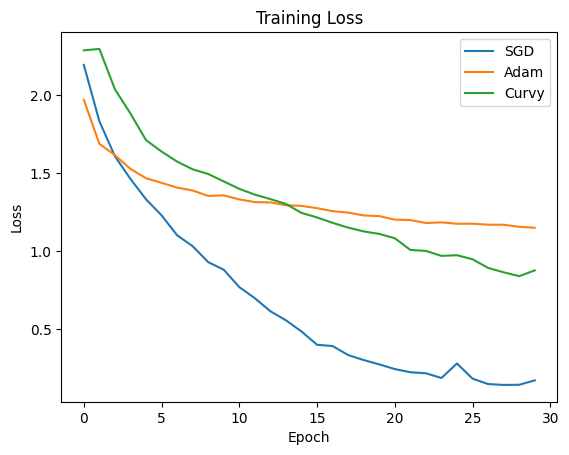

In [ ]:
plt.plot(train_losses_SGD, label='SGD')
plt.plot(train_losses_Adam, label='Adam')
plt.plot(train_losses_curvy, label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

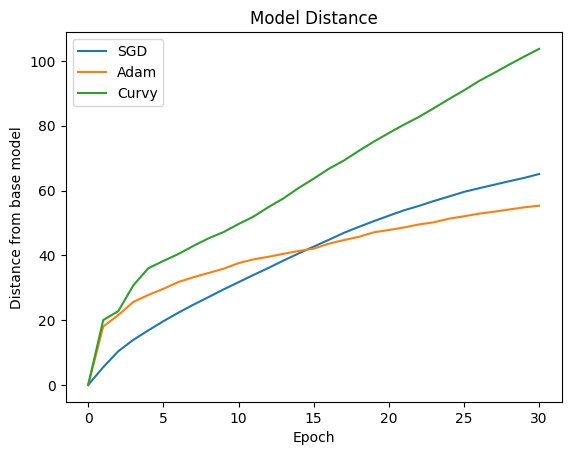

In [ ]:
plt.plot([model_distance_SGD[i].detach().item() for i in range(len(model_distance_SGD))], label='SGD')
plt.plot([model_distance_Adam[i].detach().item() for i in range(len(model_distance_Adam))], label='Adam')
plt.plot([model_distance_curvy[i].detach().item() for i in range(len(model_distance_curvy))], label='Curvy')
plt.xlabel('Epoch')
plt.ylabel('Distance from base model')
plt.title('Model Distance')
plt.legend()
plt.show()

In [ ]:
distance(model_curvy, model_Adam), distance(model_curvy, model_SGD), distance(model_Adam, model_SGD)

(tensor(114.9750, device='cuda:0', grad_fn=<AddBackward0>),
 tensor(119.8848, device='cuda:0', grad_fn=<AddBackward0>),
 tensor(80.6399, device='cuda:0', grad_fn=<AddBackward0>))